# Task B - Classification

**Scenario:** Predict whether a student will Pass or Fail using StudyHours, AttendancePercent, and AssignmentScore. Dataset: `student_classification_data.csv`

<details>
<summary><strong>Task B1</strong></summary>

Load and explore the classification dataset.

</details>

<details>
<summary><strong>Task B2</strong></summary>

Display class counts and missing values.

</details>

<details>
<summary><strong>Task B3</strong></summary>

Visualize StudyHours vs AttendancePercent for Pass and Fail.

</details>

<details>
<summary><strong>Task B4</strong></summary>

Define X and y.

</details>

<details>
<summary><strong>Task B5</strong></summary>

Split the dataset using `test_size=0.25`, `random_state=42`, `stratify=y`.

</details>

<details>
<summary><strong>Task B6</strong></summary>

Scale the features for Logistic Regression and KNN.

</details>

<details>
<summary><strong>Task B7</strong></summary>

Train and evaluate Logistic Regression.

</details>

<details>
<summary><strong>Task B8</strong></summary>

Train and evaluate KNN using `K=5`.

</details>

<details>
<summary><strong>Task B9</strong></summary>

Test K values from 1 to 20 and determine the best K.

</details>

<details>
<summary><strong>Task B10</strong></summary>

Train and evaluate Gaussian Naive Bayes.

</details>

<details>
<summary><strong>Task B11</strong></summary>

Create a comparison table containing Accuracy, Precision, Recall, and F1-score for all three models.

</details>

<details>
<summary><strong>Task B12</strong></summary>

Plot the confusion matrix for the best-performing model.

</details>

<details>
<summary><strong>Task B13</strong></summary>

Predict the class of a new student (`StudyHours=6`, `AttendancePercent=80`, `AssignmentScore=75`).

</details>

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [170]:
# B1
df=pd.read_csv("CSVdata/student_classification_data.csv")
df.head()

,StudyHours,AttendancePercent,AssignmentScore,Result
0,3.0,94,80,Pass
1,1.9,90,75,Pass
2,9.4,48,79,Pass
3,8.3,87,33,Pass
4,4.7,87,34,Pass


In [171]:
# B2
print("Class Counts : \n",df['Result'].value_counts())
print("\nMissing Values :\n",df.isnull().sum())

Class Counts : 
 Result
Pass    77
Fail    73
Name: count, dtype: int64

Missing Values :
 StudyHours           0
AttendancePercent    0
AssignmentScore      0
Result               0
dtype: int64


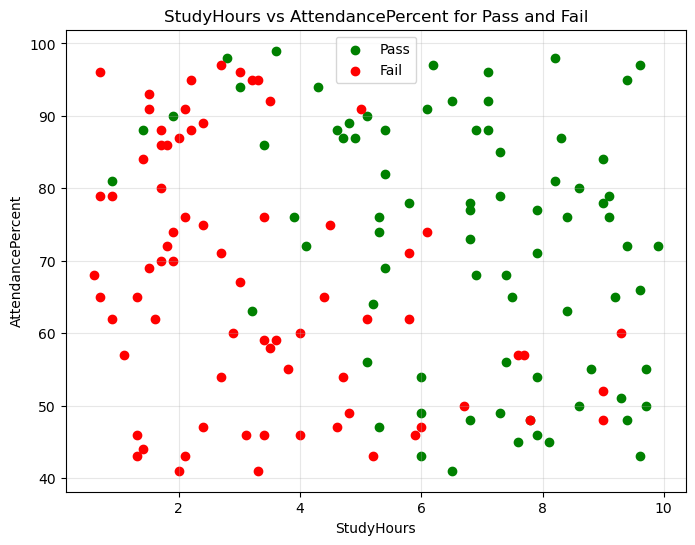

In [172]:
# B3
plt.figure(figsize=(8,6))

plt.scatter(df[df['Result']=='Pass']['StudyHours'],df[df['Result']=='Pass']['AttendancePercent'],c='g',label='Pass')
plt.scatter(df[df['Result']=='Fail']['StudyHours'],df[df['Result']=='Fail']['AttendancePercent'],c='r',label='Fail')
plt.xlabel("StudyHours")
plt.ylabel("AttendancePercent")
plt.title("StudyHours vs AttendancePercent for Pass and Fail")
plt.grid(alpha=0.3)
plt.legend()


In [173]:
# B4
X=df.drop(columns=['Result'])
y=df['Result']

In [174]:
#B5
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [175]:
# B6
from sklearn.preprocessing import StandardScaler


scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)



In [176]:
# B7
from sklearn.linear_model import LogisticRegression

model_logistic=LogisticRegression()
model_logistic.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model_logistic.predict(x_test)
print(y_pred)

['Pass' 'Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail'
 'Fail' 'Fail' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Fail' 'Fail' 'Fail'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail']


In [178]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    f1_score
)

accuracy_logistic=round(accuracy_score(y_test,y_pred),3)
precision_logistic=round(precision_score(y_test,y_pred,pos_label='Pass'),3)
recall_logistic=round(recall_score(y_test,y_pred,pos_label='Pass'),3)
f1_score_logistic=round(f1_score(y_test,y_pred,pos_label='Pass'),3)

print("Accuracy of Logistic Model : ",accuracy_logistic)
print("Precision of Logistic Model : ",precision_logistic)
print("Recall of Logistic Model : ",recall_logistic)
print("f1_score of Logistic Model :",f1_score_logistic)
print("Classification_report of Logisitic Model :\n",classification_report(y_test,y_pred,zero_division=0))



Accuracy of Logistic Model :  0.921
Precision of Logistic Model :  0.87
Recall of Logistic Model :  1.0
f1_score of Logistic Model : 0.93
Classification_report of Logisitic Model :
               precision    recall  f1-score   support

        Fail       1.00      0.83      0.91        18
        Pass       0.87      1.00      0.93        20

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.93      0.92      0.92        38



In [179]:
# B8
from sklearn.neighbors import KNeighborsClassifier

model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train,y_train)

KNeighborsClassifier()

In [180]:
y_pred=model_knn.predict(x_test)
print(y_pred)

['Fail' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Fail' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Fail' 'Fail' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Fail']


In [181]:
accuracy_knn=round(accuracy_score(y_test,y_pred),3)
precision_knn=round(precision_score(y_test,y_pred,pos_label='Pass'),3)
recall_knn=round(recall_score(y_test,y_pred,pos_label='Pass'),3)
f1_score_knn=round(f1_score(y_test,y_pred,pos_label='Pass'),3)

print("Accuracy of Knn Classifier Model : ",accuracy_knn)
print("Precision of Knn Classifier Model : ",precision_knn)
print("Recall of Knn Classifier Model : ",recall_knn)
print("f1_score of Knn Classifier Model :",f1_score_knn)

Accuracy of Knn Classifier Model :  0.842
Precision of Knn Classifier Model :  0.792
Recall of Knn Classifier Model :  0.95
f1_score of Knn Classifier Model : 0.864


In [182]:
# B9
scores=[]

for k in range(1,21):
    model_knn=KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(x_train,y_train)
    y_pred=model_knn.predict(x_test)
    accuracy_knn=round(accuracy_score(y_test,y_pred),3)
    scores.append(accuracy_knn)

best_k=scores.index(max(scores))+1
print(best_k)   

3


In [183]:
# B10
from sklearn.naive_bayes import GaussianNB

model_nb=GaussianNB()
model_nb.fit(x_train,y_train)

GaussianNB()

In [184]:
y_pred=model_nb.predict(x_test)

In [185]:
accuracy_nb=round(accuracy_score(y_test,y_pred),3)
precision_nb=round(precision_score(y_test,y_pred,pos_label='Pass'),3)
recall_nb=round(recall_score(y_test,y_pred,pos_label='Pass'),3)
f1_score_nb=round(f1_score(y_test,y_pred,pos_label='Pass'),3)

print("Accuracy of GaussianNB Classifier Model : ",accuracy_nb)
print("Precision of GaussianNB Classifier Model : ",precision_nb)
print("Recall of GaussianNB Classifier Model : ",recall_nb)
print("f1_score of GaussianNB Classifier Model :",f1_score_nb)

Accuracy of GaussianNB Classifier Model :  0.895
Precision of GaussianNB Classifier Model :  0.864
Recall of GaussianNB Classifier Model :  0.95
f1_score of GaussianNB Classifier Model : 0.905


In [186]:
# B11
Comparision=pd.DataFrame({
    "Model":["LogisticRegression","KNN_Classifier","GaussianNB"],
    "Accuracy":[accuracy_logistic,accuracy_knn,accuracy_nb],
    "Precision":[precision_logistic,precision_knn,precision_nb],
    "Recall":[recall_logistic,recall_knn,recall_nb],
    "F1_Score":[f1_score_logistic,f1_score_knn,f1_score_nb]
})

print(Comparision.to_string())

                Model  Accuracy  Precision  Recall  F1_Score
0  LogisticRegression     0.921      0.870    1.00     0.930
1      KNN_Classifier     0.868      0.792    0.95     0.864
2          GaussianNB     0.895      0.864    0.95     0.905


The Best Performing Model is : Logistic Regression


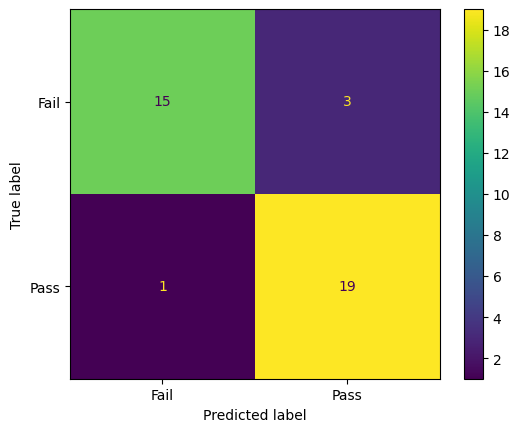

In [187]:
#  B12
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay)
print("The Best Performing Model is : Logistic Regression")

cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Fail","Pass"])

disp.plot()

In [193]:

print(f"New Student with StudyHours = 6 , AttendancePercent = 80 and AssignmentScore = 75  Will ->>>>>>>  {model_logistic.predict([[6,80,75]])[0]}")

New Student with StudyHours = 6 , AttendancePercent = 80 and AssignmentScore = 75  Will ->>>>>>>  Pass
